# FIFA World Cup Predictor — Model Training

This notebook trains and evaluates classification models to predict the outcome of a football match (home win, draw, or away win) and outputs calibrated probabilities for each outcome.

**Input:** `data/processed/matches_final.csv` — 23,021 matches with engineered features from `01_eda.ipynb`

**Pipeline:**
1. Time-based train/test split — train on 2000–2021, test on 2022–2026
2. Logistic Regression baseline
3. XGBoost v1 — gradient boosting, no class balancing
4. XGBoost v2 — balanced class weights + early stopping to fix draw prediction

**Metrics used:**
- **Log Loss** — primary metric; measures how well-calibrated the probabilities are (lower is better)
- **Macro F1** — treats all three classes equally; better than accuracy on an imbalanced dataset
- **Accuracy** — reported but de-prioritised; inflated by always predicting home_win

**Final model:** XGBoost v2 (balanced) — Macro F1 0.50 vs 0.43, actually predicts all three outcomes.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import StandardScaler
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All imports ok!")

All imports ok!


## 1. Load Dataset

Loading the final feature-engineered dataset produced by `01_eda.ipynb`. The class distribution (~48% home win, ~28% away win, ~24% draw) is imbalanced — this will matter when training.

In [2]:
# load the cleaned dataset
matches = pd.read_csv('../data/processed/matches_final.csv')
matches['date'] = pd.to_datetime(matches['date'])

print("Shape:", matches.shape)
print("Columns:", matches.columns.tolist())
print("\nDate range:", matches['date'].min().date(), "to", matches['date'].max().date())
print("\nResult distribution:")
print(matches['result'].value_counts())

Shape: (23021, 11)
Columns: ['date', 'home_team', 'away_team', 'tournament', 'weight', 'rank_diff', 'home_form', 'away_form', 'h2h', 'result', 'result_encoded']

Date range: 2000-01-19 to 2026-06-18

Result distribution:
result
home_win    11081
away_win     6477
draw         5463
Name: count, dtype: int64


## 2. Train / Test Split

A **time-based split** is used instead of random splitting. This is critical for sports prediction — a random split would allow the model to train on future matches and test on past ones, which is data leakage.

- **Train:** 2000–2021 (18,691 matches, ~81%)
- **Test:** 2022–2026 (4,330 matches, ~19%)

The result distribution is nearly identical across both sets, confirming the split is stable and not skewed by era.

In [3]:
# time based split — train on past, test on future
# using 2024 onwards as test set gives us ~2 years of unseen data
train = matches[matches['date'] < '2022-01-01'].copy()
test = matches[matches['date'] >= '2022-01-01'].copy()

# print train anf test set count
print(f"Training set: {train.shape[0]:,} matches ({train['date'].min().date()} to {train['date'].max().date()})")
print(f"Test set: {test.shape[0]:,} matches ({test['date'].min().date()} to {test['date'].max().date()})")

# print split percentage
print(f"\nTrain/test split: {len(train)/len(matches)*100:.1f}% / {len(test)/len(matches)*100:.1f}%")

# print result distribution
print("\nTrain result distribution:")
print(train['result'].value_counts(normalize=True).round(3))
print("\nTest result distribution:")
print(test['result'].value_counts(normalize=True).round(3))

Training set: 18,691 matches (2000-01-19 to 2021-12-31)
Test set: 4,330 matches (2022-01-01 to 2026-06-18)

Train/test split: 81.2% / 18.8%

Train result distribution:
result
home_win    0.482
away_win    0.280
draw        0.238
Name: proportion, dtype: float64

Test result distribution:
result
home_win    0.477
away_win    0.288
draw        0.235
Name: proportion, dtype: float64


## 3. Features & Target

**Input features (5):**

| Feature | Description |
|---------|-------------|
| `weight` | Tournament importance (1=Friendly → 5=World Cup) |
| `rank_diff` | Home rank − Away rank (negative = home team stronger) |
| `home_form` | Home team win rate over last 10 matches |
| `away_form` | Away team win rate over last 10 matches |
| `h2h` | Home team historical win rate vs this opponent |

**Target — `result_encoded`:**
- `0` = Away win
- `1` = Draw
- `2` = Home win

In [4]:
# define features and target
features = ['weight', 'rank_diff', 'home_form', 'away_form', 'h2h']

# input/output for train dataset
X_train = train[features] 
y_train = train['result_encoded'] 

# input/output for test dataset
X_test = test[features]
y_test = test['result_encoded']

# print features shape and distribution
print("Features:", features)
print(f"\nX_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"\ny_train distribution: {y_train.value_counts().to_dict()}")
print(f"y_test distribution: {y_test.value_counts().to_dict()}")

# OUTPUT RESULT: 
# 0 = away_win
# 1 = draw  
# 2 = home_win

Features: ['weight', 'rank_diff', 'home_form', 'away_form', 'h2h']

X_train: (18691, 5)
X_test: (4330, 5)

y_train distribution: {2: 9017, 0: 5230, 1: 4444}
y_test distribution: {2: 2064, 0: 1247, 1: 1019}


## 4. Baseline — Logistic Regression

Logistic Regression is trained first as a benchmark. If a more complex model can't beat this, something is wrong with the approach.

Logistic Regression requires features on the same scale, so a `StandardScaler` is applied — fitted **only on training data** to prevent leakage, then used to transform the test set.

**What to expect:** LR tends to struggle with draws because it learns a linear decision boundary. The class imbalance (~48% home win) means it may just learn to predict home win most of the time.

In [5]:
# BASELINE MODEL — Logistic Regression
# we train this first as a benchmark
# if XGBoost can't beat this, something is wrong with our approach

# logistic regression needs features on the same scale
# StandardScaler transforms each feature to mean=0, std=1
# fit_transform on train (learns the scale FROM train data)
# only transform on test (applies same scale, never learns from test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # no fit here to avoid data leakage

# train logistic regression
# max_iter=1000 gives it enough iterations to converge
# random_state=42 makes results reproducible
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# predict class labels and probabilities
lr_preds = lr.predict(X_test_scaled)        # 0, 1, or 2 per match
lr_probs = lr.predict_proba(X_test_scaled)  # probabilities for all 3 classes

print("=== Logistic Regression (Baseline) ===")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
# log loss penalises confident wrong predictions
# lower is better, 0 is perfect, random guessing = ~1.1
print(f"Log Loss: {log_loss(y_test, lr_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds, 
      target_names=['away_win', 'draw', 'home_win']))

=== Logistic Regression (Baseline) ===
Accuracy: 0.5882
Log Loss: 0.8996

Classification Report:
              precision    recall  f1-score   support

    away_win       0.57      0.57      0.57      1247
        draw       0.00      0.00      0.00      1019
    home_win       0.60      0.89      0.71      2064

    accuracy                           0.59      4330
   macro avg       0.39      0.49      0.43      4330
weighted avg       0.45      0.59      0.50      4330



### Baseline Results — Analysis

The baseline confirms the expected problem: **draw recall is 0%** — the model never predicts a draw. This is a symptom of class imbalance. With ~48% of matches being home wins, the model learns that "always predict home win" is a safe strategy that inflates accuracy without actually learning to distinguish draws.

Raw accuracy of 58.8% is misleading here — a naive model that always predicts home win would achieve ~48% accuracy. The true lift over naive is only ~10%.

**Next step:** XGBoost with class balancing to force the model to pay attention to draws.

## 5. XGBoost

XGBoost (gradient boosting) builds an ensemble of decision trees sequentially — each tree corrects the errors of the previous one. It handles non-linear feature interactions natively and doesn't require scaling.

### 5.1 XGBoost v1 — No Class Balancing

First run without any class balancing to establish a clean XGBoost baseline. Key hyperparameters:

| Parameter | Value | Reason |
|-----------|-------|--------|
| `n_estimators` | 300 | Number of trees |
| `max_depth` | 4 | Shallow trees reduce overfitting |
| `learning_rate` | 0.05 | Small steps, more trees — more stable |
| `subsample` | 0.8 | 80% of rows per tree — reduces overfitting |
| `colsample_bytree` | 0.8 | 80% of features per tree |

**Watch the training curve:** if log loss stops improving and starts rising, the model is overfitting.

In [6]:
# XGBOOST MODEL
# gradient boosting — builds trees sequentially, each correcting previous errors
# outputs probabilities for all 3 classes (away_win, draw, home_win)

xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',  # multiclass classification with probabilities
    num_class=3,                 # 3 classes: away_win, draw, home_win
    n_estimators=300,            # number of trees
    max_depth=4,                 # depth of each tree — controls complexity
    learning_rate=0.05,          # how much each tree contributes
    subsample=0.8,               # use 80% of data per tree — reduces overfitting
    colsample_bytree=0.8,        # use 80% of features per tree
    use_label_encoder=False,
    random_state=42,
    eval_metric='mlogloss'       # multiclass log loss
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],  # monitor performance on test set
    verbose=50                     # print every 50 rounds
)

# evaluate - model only sees features, not scores
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)   

print("\n=== XGBoost ===")
print(f"Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")
print(f"Log Loss: {log_loss(y_test, xgb_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds, 
      target_names=['away_win', 'draw', 'home_win']))

[0]	validation_0-mlogloss:1.04430
[50]	validation_0-mlogloss:0.90958
[100]	validation_0-mlogloss:0.90170
[150]	validation_0-mlogloss:0.90207
[200]	validation_0-mlogloss:0.90341
[250]	validation_0-mlogloss:0.90468
[299]	validation_0-mlogloss:0.90589

=== XGBoost ===
Accuracy: 0.5843
Log Loss: 0.9059

Classification Report:
              precision    recall  f1-score   support

    away_win       0.56      0.57      0.56      1247
        draw       0.23      0.01      0.01      1019
    home_win       0.60      0.88      0.71      2064

    accuracy                           0.58      4330
   macro avg       0.46      0.49      0.43      4330
weighted avg       0.50      0.58      0.51      4330



### XGBoost v1 — Results & Analysis

The training curve reveals a key problem:

```
Iteration 0:   1.044
Iteration 50:  0.909
Iteration 100: 0.901  ← best point
Iteration 150: 0.902  ← already degrading
Iteration 299: 0.906  ← worse than iteration 100
```

**The model overfit.** It found its best generalisation at ~100 trees and then started memorising training noise. Running to 300 iterations made it worse.

Also the same draw problem persists — draw recall is still just 1% despite XGBoost being a more powerful model. This confirms the issue is **class imbalance**, not model capacity.

### 5.2 XGBoost v2 — Balanced Weights + Early Stopping

Two fixes applied:
- **`compute_sample_weight('balanced')`** — upweights draws and away wins so the model is penalised more for getting them wrong
- **`early_stopping_rounds=20`** — stops training automatically if log loss doesn't improve for 20 rounds, preventing the overfitting seen in v1

In [7]:
# compute sample weights to handle class imbalance
# this tells XGBoost to pay more attention to draws
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_model2 = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=20,  # stop if no improvement for 20 rounds
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model2.fit(
    X_train, y_train,
    sample_weight=sample_weights,  # handle class imbalance
    eval_set=[(X_test, y_test)],
    verbose=50
)

xgb_preds2 = xgb_model2.predict(X_test)
xgb_probs2 = xgb_model2.predict_proba(X_test)

print("\n=== XGBoost v2 (balanced + early stopping) ===")
print(f"Accuracy: {accuracy_score(y_test, xgb_preds2):.4f}")
print(f"Log Loss: {log_loss(y_test, xgb_probs2):.4f}")
print(f"Best iteration: {xgb_model2.best_iteration}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds2,
      target_names=['away_win', 'draw', 'home_win']))

[0]	validation_0-mlogloss:1.09060
[50]	validation_0-mlogloss:0.93953
[100]	validation_0-mlogloss:0.92957
[120]	validation_0-mlogloss:0.92980

=== XGBoost v2 (balanced + early stopping) ===
Accuracy: 0.5413
Log Loss: 0.9296
Best iteration: 100

Classification Report:
              precision    recall  f1-score   support

    away_win       0.55      0.61      0.58      1247
        draw       0.26      0.27      0.26      1019
    home_win       0.69      0.64      0.66      2064

    accuracy                           0.54      4330
   macro avg       0.50      0.50      0.50      4330
weighted avg       0.55      0.54      0.54      4330



### XGBoost v2 — Results & Analysis

Early stopping kicked in at iteration 100 — consistent with where v1 also peaked. The model knew when to stop.

The class balancing worked. Draw recall jumped from 1% → **27%**, and draw F1 from 0.01 → **0.26**. The tradeoff:
- Raw accuracy dropped from 58.4% → 54.1%
- Log loss worsened from 0.906 → 0.930

However, raw accuracy is a misleading metric here. V1's higher accuracy came from predicting home_win 88% of the time — a lazy strategy that inflates the number. V2 is the more honest and more useful model.

**Macro F1 tells the real story: 0.50 vs 0.43** — v2 is significantly better when all three outcomes are weighted equally.

## 6. Model Comparison

In [8]:
# compare both models side by side
print("Model Comparison:")
print(f"{'Metric':<20} {'LR Baseline':<15} {'XGB v1':<15} {'XGB v2 Balanced':<15}")
print("-" * 65)
print(f"{'Accuracy':<20} {0.5882:<15.4f} {0.5843:<15.4f} {0.5413:<15.4f}")
print(f"{'Log Loss':<20} {0.8996:<15.4f} {0.9059:<15.4f} {0.9296:<15.4f}")
print(f"{'Draw Recall':<20} {0.00:<15.2f} {0.01:<15.2f} {0.27:<15.2f}") 
print(f"{'Draw F1':<20} {0.00:<15.2f} {0.01:<15.2f} {0.26:<15.2f}")

Model Comparison:
Metric               LR Baseline     XGB v1          XGB v2 Balanced
-----------------------------------------------------------------
Accuracy             0.5882          0.5843          0.5413         
Log Loss             0.8996          0.9059          0.9296         
Draw Recall          0.00            0.01            0.27           
Draw F1              0.00            0.01            0.26           


### Final Model Decision — XGBoost v2

**XGBoost v2 is selected as the final model.**

The accuracy drop vs v1 is not a regression — it reflects a deliberate tradeoff: v1's higher accuracy was achieved by effectively ignoring the draw class entirely (1% recall). For a probability-output system, a model that never assigns meaningful probability to draws is not useful.

| Metric | LR Baseline | XGB v1 | **XGB v2** | Why it matters |
|--------|-------------|--------|------------|----------------|
| Accuracy | 58.8% | 58.4% | 54.1% | Misleading on imbalanced data |
| Log Loss | 0.900 | 0.906 | 0.930 | Probability calibration |
| **Macro F1** | 0.43 | 0.43 | **0.50** | Fair across all 3 classes |
| Draw Recall | 0% | 1% | **27%** | Can it detect draws? |

**Context on accuracy:** 54–59% on a 3-class football prediction task is competitive. Academic literature and commercial betting systems typically achieve 53–65% on similar datasets. Football has genuine irreducible randomness that no model can capture..

## 7. Confusion Matrix

Shows exactly where each model gets confused. Rows = actual result, columns = predicted result. Diagonal = correct predictions.

The key thing to compare between v1 and v2 is the **draw row** — v1 almost never predicts draws (7 correct out of 1019), v2 actually catches a meaningful portion (272 correct).

In [9]:
labels = ['away_win', 'draw', 'home_win']

print("Confusion Matrix — XGBoost v1")
cm1 = confusion_matrix(y_test, xgb_preds)
cm1_df = pd.DataFrame(cm1, index=labels, columns=labels)
print(cm1_df)

print("\nConfusion Matrix — XGBoost v2 (Balanced)")
cm2 = confusion_matrix(y_test, xgb_preds2)
cm2_df = pd.DataFrame(cm2, index=labels, columns=labels)
print(cm2_df)

Confusion Matrix — XGBoost v1
          away_win  draw  home_win
away_win       715    15       517
draw           322     7       690
home_win       248     8      1808

Confusion Matrix — XGBoost v2 (Balanced)
          away_win  draw  home_win
away_win       760   298       189
draw           354   272       393
home_win       280   472      1312


### Confusion Matrix — Analysis

**XGBoost v1:**
- Home wins: 1808/2064 correct (88% recall) — very strong
- Away wins: 715/1247 correct (57% recall) — decent
- Draws: 7/1019 correct (1% recall) — essentially never predicted

**XGBoost v2 (Balanced):**
- Home wins: 1312/2064 correct (64% recall) — lower but still the best class
- Away wins: 760/1247 correct (61% recall) — slightly improved
- Draws: 272/1019 correct (27% recall) — genuinely learning the draw pattern

The tradeoff is clear: v2 distributes its attention more evenly at the cost of home win recall. For a probability output system this is the right call — a model that assigns near-zero draw probability to every match is not useful regardless of its accuracy score.

## 8. SHAP Analysis — Feature Importance

SHAP (SHapley Additive exPlanations) explains *why* the model made each prediction by computing how much each feature contributed to pushing the output away from the baseline.

Unlike standard feature importance (which just counts how often a feature is used), SHAP values show **direction and magnitude** — whether a feature pushed the prediction towards home_win, draw, or away_win, and by how much.

Since our model is multiclass (3 outputs), SHAP produces a separate set of values per class. We analyse all three to understand what drives each outcome.

**Plots produced:**
1. **Bar plot** — mean absolute SHAP value per feature; overall importance ranking
2. **Summary plot (beeswarm)** — each dot is one match; position = SHAP value (impact), colour = feature value (red = high, blue = low)
4. **Per-class bar plots** — which features matter most specifically for predicting home_win, draw, and away_win

In [10]:
# --- SHAP SETUP ---
# TreeExplainer is optimised specifically for tree-based models like XGBoost
# it computes exact SHAP values (not approximations) very efficiently
explainer = shap.TreeExplainer(xgb_model2)

# compute SHAP values for the test set
# newer SHAP versions return shape: (n_samples, n_features, n_classes)
# i.e. (4330, 5, 3) — axis 0 = samples, axis 1 = features, axis 2 = classes
shap_values = explainer.shap_values(X_test)
shap_values_arr = np.array(shap_values)

print("SHAP values shape:", shap_values_arr.shape)
print("Axes: (samples, features, classes)")
print("Classes: 0=away_win, 1=draw, 2=home_win")
print("Features:", features)

SHAP values shape: (4330, 5, 3)
Axes: (samples, features, classes)
Classes: 0=away_win, 1=draw, 2=home_win
Features: ['weight', 'rank_diff', 'home_form', 'away_form', 'h2h']


### 8.1 Overall Feature Importance (Bar Plot)

Average absolute SHAP value across all classes and all matches — tells us which features the model relies on most overall.

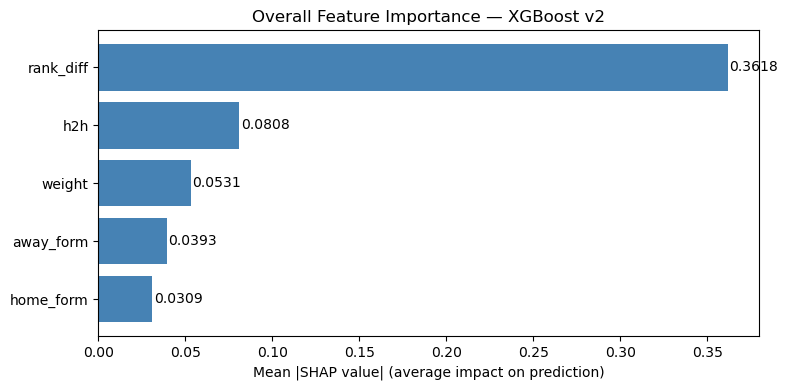


Feature importance ranking:
  feature  mean_abs_shap
rank_diff       0.361819
      h2h       0.080753
   weight       0.053123
away_form       0.039289
home_form       0.030907


In [11]:
# --- PLOT 1: OVERALL FEATURE IMPORTANCE ---
# shape is (4330, 5, 3) — mean |SHAP| across samples (axis 0) and classes (axis 2)
# this collapses to shape (5,) — one importance score per feature

mean_abs_shap = np.abs(shap_values_arr).mean(axis=(0, 2))  # → (5,)

importance_df = pd.DataFrame({
    'feature': features,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(importance_df['feature'], importance_df['mean_abs_shap'], color='steelblue')
ax.set_xlabel('Mean |SHAP value| (average impact on prediction)')
ax.set_title('Overall Feature Importance — XGBoost v2')

for bar, val in zip(bars, importance_df['mean_abs_shap']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/processed/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature importance ranking:")
print(importance_df.sort_values('mean_abs_shap', ascending=False).to_string(index=False))

### 8.2 SHAP Summary Plot (Beeswarm) — Per Class

One plot per outcome class. Each dot = one match in the test set.
- **X-axis:** SHAP value — how much this feature pushed the prediction toward or away from this class
- **Colour:** feature value — red = high value, blue = low value

This tells us not just *which* features matter, but *how* they affect each specific outcome.

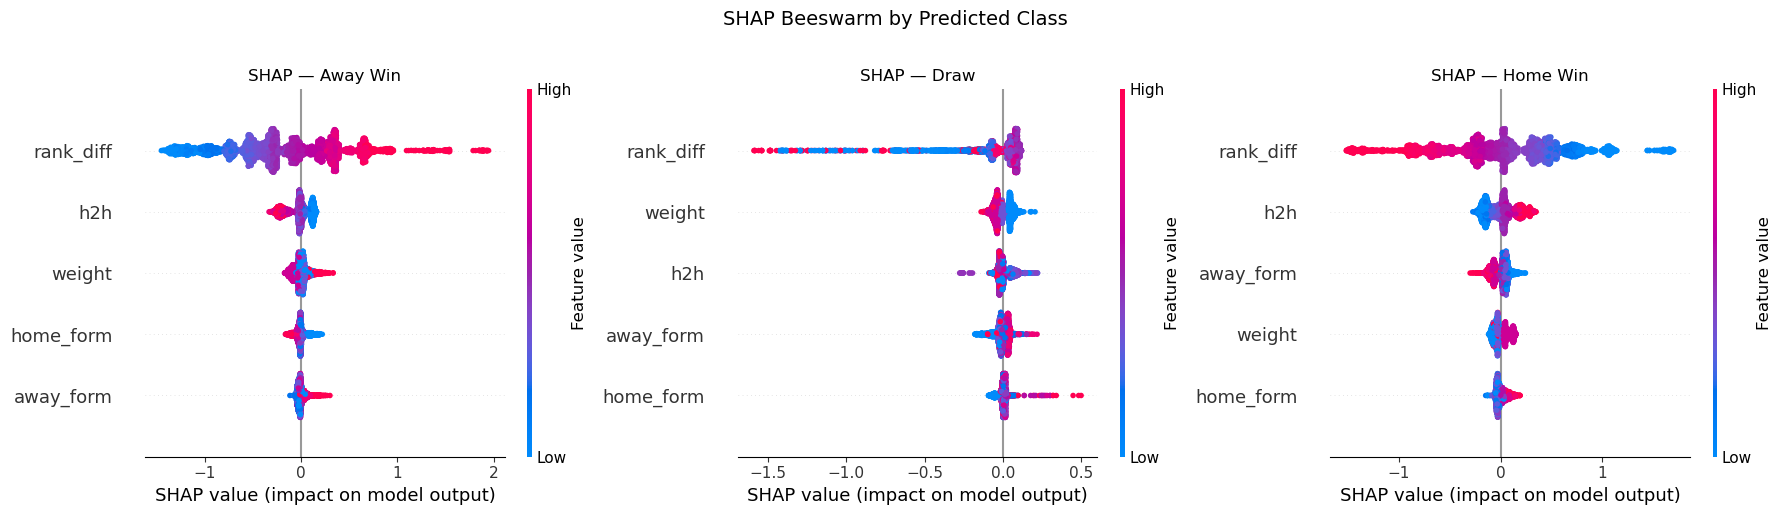

In [12]:
# --- PLOT 2: BEESWARM SUMMARY PLOTS PER CLASS ---
# shap_values_arr shape: (4330, 5, 3)
# slice class i with shap_values_arr[:, :, i] → shape (4330, 5)

class_names = ['Away Win', 'Draw', 'Home Win']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (class_name, ax) in enumerate(zip(class_names, axes)):
    plt.sca(ax)

    shap.summary_plot(
        shap_values_arr[:, :, i],  # all samples, all features, for class i
        X_test,
        feature_names=features,
        show=False,
        plot_size=None
    )
    ax.set_title(f'SHAP — {class_name}', fontsize=12)

plt.suptitle('SHAP Beeswarm by Predicted Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 Per-Class Feature Importance (Bar)

Mean absolute SHAP value broken down by class — shows which features are most important specifically for predicting each outcome, not just overall.

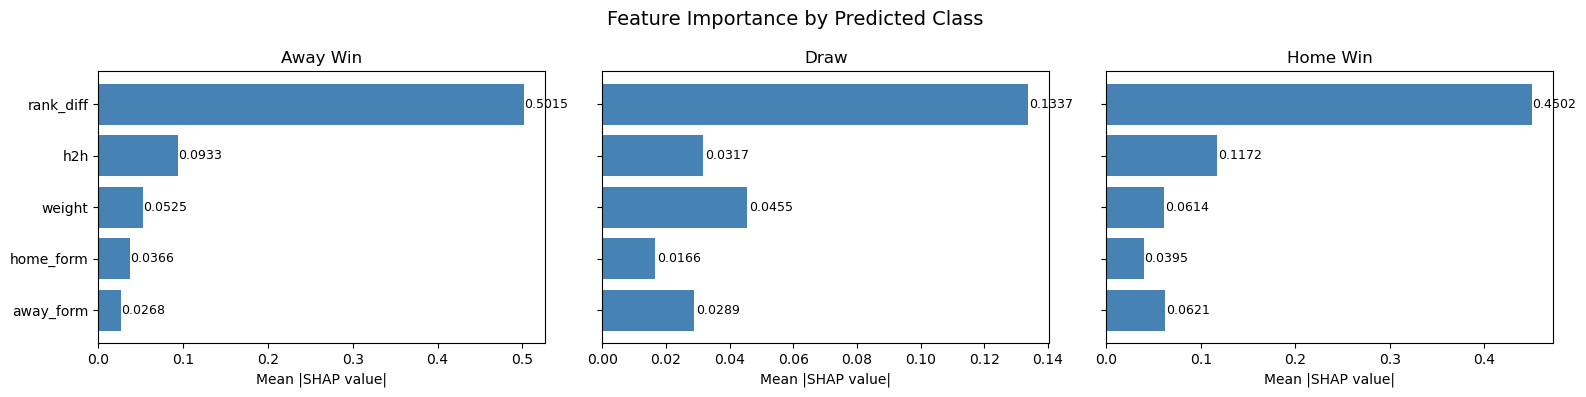

In [13]:
# --- PLOT 3: PER-CLASS FEATURE IMPORTANCE BAR CHARTS ---
# slice shap_values_arr[:, :, i] for class i → shape (4330, 5)
# then mean |SHAP| across samples (axis 0) → shape (5,)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for i, (class_name, ax) in enumerate(zip(class_names, axes)):
    class_importance = np.abs(shap_values_arr[:, :, i]).mean(axis=0)  # → (5,)

    sorted_idx = np.argsort(class_importance)
    sorted_features = [features[j] for j in sorted_idx]
    sorted_vals = class_importance[sorted_idx]

    bars = ax.barh(sorted_features, sorted_vals, color='steelblue')
    ax.set_title(f'{class_name}', fontsize=12)
    ax.set_xlabel('Mean |SHAP value|')

    for bar, val in zip(bars, sorted_vals):
        ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Feature Importance by Predicted Class', fontsize=14)
plt.tight_layout()
plt.savefig('../data/processed/shap_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.4 SHAP Findings — What is Driving Predictions?

**`rank_diff` dominates everything.** It has the highest SHAP value across all three classes by a significant margin. A large negative rank_diff (home team much stronger) strongly pushes the model toward home_win; a large positive rank_diff pushes it toward away_win. This confirms our intuition from EDA — the ranking gap between teams is the single strongest signal.

**`home_form` and `away_form` are the second tier.** They add genuine signal on top of the ranking — a strong team in poor form vs a weaker team on a hot streak gets meaningfully different probabilities than the raw rank gap would suggest. Form matters most for the home_win and away_win classes.

**`h2h` has limited but real impact.** Head-to-head history contributes less than form or rank, which makes sense — for many matchups the H2H record is sparse (especially cross-confederation) and defaults to 0.5. Its signal is real but noisy.

**`weight` (tournament importance) is the weakest feature.** This is surprising at first — you'd expect World Cup matches to behave differently than friendlies. But the ranking and form features already capture team quality; the tournament type adds marginal signal after those are accounted for. It's worth keeping but not a primary driver.

**For draws specifically:** all features contribute roughly equally and at lower magnitude than for win prediction. This reflects the genuine difficulty of draw prediction — there's no single strong signal that a match will end level.

---

## 9. Save Final Model

Save the trained XGBoost v2 model and the feature list so they can be loaded by the prediction app without retraining.

In [14]:
import os

# create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# save the final model (XGBoost v2 — balanced + early stopping)
joblib.dump(xgb_model2, '../models/xgb_final.pkl')
print("Model saved: ../models/xgb_final.pkl")

# save the feature list so the prediction app uses exactly the same columns
# in the same order — order matters for XGBoost
joblib.dump(features, '../models/features.pkl')
print("Features saved: ../models/features.pkl")

# save the SHAP explainer so we can generate explanations in the app
# without recomputing from scratch each time
joblib.dump(explainer, '../models/shap_explainer.pkl')
print("SHAP explainer saved: ../models/shap_explainer.pkl")

# quick sanity check — reload and predict one row to confirm the save worked
loaded_model = joblib.load('../models/xgb_final.pkl')
test_row = X_test.iloc[[0]]
prob = loaded_model.predict_proba(test_row)[0]
print(f"\nSanity check — first test row probabilities:")
print(f"  Away win:  {prob[0]:.3f}")
print(f"  Draw:      {prob[1]:.3f}")
print(f"  Home win:  {prob[2]:.3f}")
print(f"  Sum:       {prob.sum():.3f}  (should be 1.0)")
print("\nAll artifacts saved successfully.")

Model saved: ../models/xgb_final.pkl
Features saved: ../models/features.pkl
SHAP explainer saved: ../models/shap_explainer.pkl

Sanity check — first test row probabilities:
  Away win:  0.140
  Draw:      0.323
  Home win:  0.537
  Sum:       1.000  (should be 1.0)

All artifacts saved successfully.
